Install requirements.txt

In [8]:
pip install -r ../requirements.txt

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# DATA SETUP (Based on Table VI and Fig 2)
# ==========================================
data = {
    'Technique': ['Rule-Based', 'Cost-Based', 'Adaptive', 'ML-Based'],
    'Avg_Query_Latency_ms': [200, 110, 90, 70],  # Fig 2 Data
    'CPU_Utilization_Pct': [25, 42.5, 50, 65],   # Midpoints from Table VI
    'Scalability_Index': [0.2, 0.5, 0.8, 0.95],  # Normalized 0-1 based on Table VIII
    'System_Overhead': [10, 40, 60, 90]          # Conceptual score for Fig 5
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")


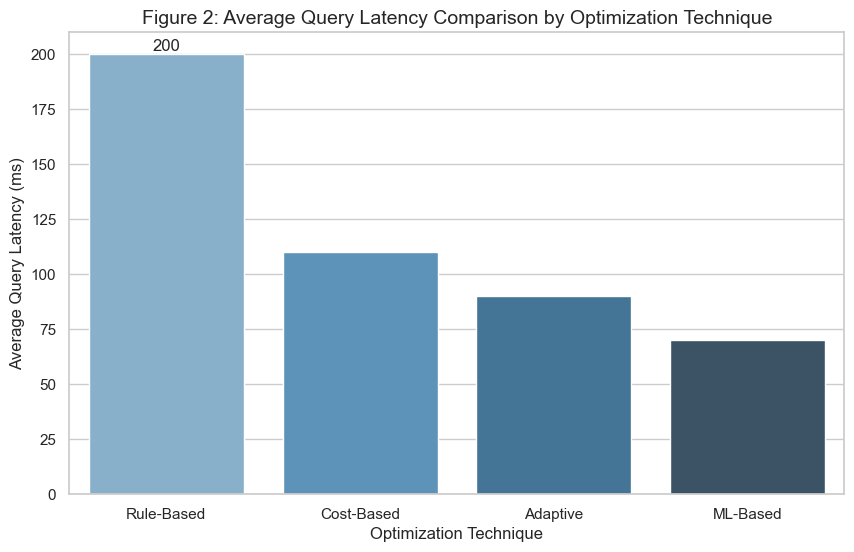

In [4]:
# ==========================================
# FIGURE 2: Average Query Latency Comparison
# Supports Section IV.B
# ==========================================
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Technique', y='Avg_Query_Latency_ms', data=df, palette="Blues_d")
plt.title('Figure 2: Average Query Latency Comparison by Optimization Technique', fontsize=14)
plt.ylabel('Average Query Latency (ms)')
plt.xlabel('Optimization Technique')
plt.bar_label(barplot.containers[0])
plt.savefig('../results/fig2_latency_comparison.png')
plt.show()


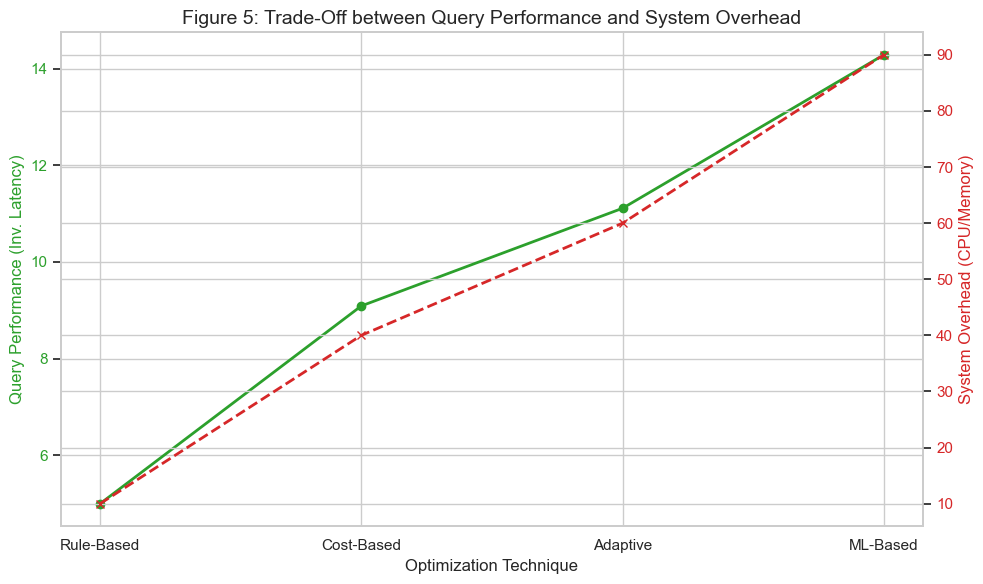

In [5]:
# ==========================================
# FIGURE 5: Performance vs. Overhead Trade-off
# Supports Section IV.F
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:green'
ax1.set_xlabel('Optimization Technique', fontsize=12)
ax1.set_ylabel('Query Performance (Inv. Latency)', color=color, fontsize=12)
# Inverting latency to represent "Performance Gain"
ax1.plot(df['Technique'], 1000/df['Avg_Query_Latency_ms'], color=color, marker='o', linewidth=2, label='Query Performance')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('System Overhead (CPU/Memory)', color=color, fontsize=12)
ax2.plot(df['Technique'], df['System_Overhead'], color=color, marker='x', linestyle='--', linewidth=2, label='System Overhead')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Figure 5: Trade-Off between Query Performance and System Overhead', fontsize=14)
fig.tight_layout()
plt.savefig('../results/fig5_performance_vs_overhead.png')
plt.show()


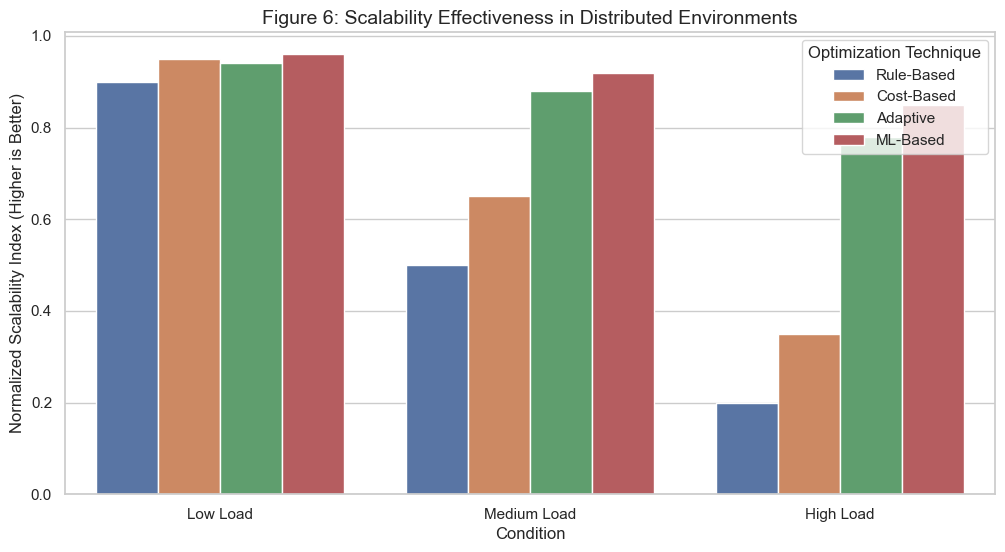

In [6]:
# ==========================================
# FIGURE 6: Scalability Effectiveness
# Supports Section IV.G
# ==========================================
scalability_data = pd.DataFrame({
    'Technique': ['Rule-Based', 'Cost-Based', 'Adaptive', 'ML-Based'] * 3,
    'Condition': ['Low Load'] * 4 + ['Medium Load'] * 4 + ['High Load'] * 4,
    'Effectiveness': [
        0.9, 0.95, 0.94, 0.96,  # Low Load (Rule-based is fine here)
        0.5, 0.65, 0.88, 0.92,  # Medium Load (Rule-based drops)
        0.2, 0.35, 0.78, 0.85   # High Load (ML/Adaptive shines)
    ]
})

plt.figure(figsize=(12, 6))
sns.barplot(x='Condition', y='Effectiveness', hue='Technique', data=scalability_data)
plt.title('Figure 6: Scalability Effectiveness in Distributed Environments', fontsize=14)
plt.ylabel('Normalized Scalability Index (Higher is Better)')
plt.legend(title='Optimization Technique')
plt.savefig('../results/fig6_scalability_trends.png')
plt.show()
